In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.feature_selection import RFE
from xgboost import XGBClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, roc_auc_score

df = pd.read_csv("kickstarter_data_full.csv", encoding="latin-1", on_bad_lines="skip")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20632 entries, 0 to 20631
Data columns (total 68 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   20632 non-null  int64  
 1   id                           20632 non-null  int64  
 2   photo                        20632 non-null  object 
 3   name                         20632 non-null  object 
 4   blurb                        20626 non-null  object 
 5   goal                         20632 non-null  float64
 6   pledged                      20632 non-null  float64
 7   state                        20632 non-null  object 
 8   slug                         20632 non-null  object 
 9   disable_communication        20632 non-null  bool   
 10  country                      20632 non-null  object 
 11  currency                     20632 non-null  object 
 12  currency_symbol              20632 non-null  object 
 13  currency_trailin

/var/folders/7_/yx515w1d5jg00cq76wbx1rvr0000gq/T/ipykernel_59024/78032279.py:12: DtypeWarning: Columns (29,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("kickstarter_data_full.csv", encoding="latin-1", on_bad_lines="skip")


In [ ]:

df['usd_goal'] = df['goal'] * df['static_usd_rate']
df.drop(['Unnamed: 0','deadline','created_at','launched_at','id','photo','name','blurb','slug', 'currency','friends',
'is_starred','is_backing','permissions', 'urls', 'source_url','profile','creator','state',"state_changed_at",
"state_changed_at_weekday","state_changed_at_month","state_changed_at_day","state_changed_at_yr",
"state_changed_at_hr","launch_to_state_change","launch_to_state_change_days", 'currency_symbol',
'currency_trailing_code', 'goal','static_usd_rate', 'location', "disable_communication","spotlight",
"staff_pick","pledged","usd_pledged","backers_count", 'create_to_launch','launch_to_deadline'], axis=1, inplace=True)


le = LabelEncoder()
df['deadline_weekday'] = le.fit_transform(df['deadline_weekday'])
df['created_at_weekday'] = le.fit_transform(df['created_at_weekday'])
df['launched_at_weekday'] = le.fit_transform(df['launched_at_weekday'])
df['category'] = le.fit_transform(df['category'])
df['country'] = le.fit_transform(df['country'])

# categorical_cols = ["country","currency","category","deadline_weekday","created_at_weekday","launched_at_weekday","deadline_month","created_at_month","launched_at_month","deadline_day","created_at_day","launched_at_day","deadline_hr","created_at_hr","launched_at_hr","USorGB","TOPCOUNTRY","LaunchedTuesday","DeadlineWeekend"]

print(df.info())
print(df.head())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20632 entries, 0 to 20631
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   country                  20632 non-null  int64  
 1   category                 20632 non-null  int64  
 2   name_len                 20627 non-null  float64
 3   name_len_clean           20627 non-null  float64
 4   blurb_len                20627 non-null  float64
 5   blurb_len_clean          20627 non-null  float64
 6   deadline_weekday         20632 non-null  int64  
 7   created_at_weekday       20632 non-null  int64  
 8   launched_at_weekday      20632 non-null  int64  
 9   deadline_month           20632 non-null  int64  
 10  deadline_day             20632 non-null  int64  
 11  deadline_yr              20632 non-null  int64  
 12  deadline_hr              20632 non-null  int64  
 13  created_at_month         20632 non-null  int64  
 14  created_at_day        

In [74]:

X = df.drop('SuccessfulBool', axis=1)
y = df['SuccessfulBool']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model = XGBClassifier()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


for i in range(5,30):
    selector = RFE(
        estimator=model,
        n_features_to_select=i, 
        step=1
    )

    selector.fit(X_train, y_train)

    selected_features = X_train.columns[selector.support_]
    print("Selected features:")
    print(selected_features)

rfecv = RFECV(
    estimator=model,
    step=1,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

rfecv.fit(X_train, y_train)

print("Optimal number of features:", rfecv.n_features_)
support_mask = rfecv.support_
selected_features = X_train.columns[support_mask]

print("Selected features:")
print(selected_features.tolist())

Selected features:
Index(['category', 'launched_at_yr', 'USorGB', 'TOPCOUNTRY', 'usd_goal'], dtype='object')
Selected features:
Index(['category', 'launched_at_yr', 'create_to_launch_days', 'USorGB',
       'TOPCOUNTRY', 'usd_goal'],
      dtype='object')
Selected features:
Index(['category', 'deadline_yr', 'launched_at_yr', 'create_to_launch_days',
       'USorGB', 'TOPCOUNTRY', 'usd_goal'],
      dtype='object')
Selected features:
Index(['category', 'name_len', 'deadline_yr', 'launched_at_yr',
       'create_to_launch_days', 'USorGB', 'TOPCOUNTRY', 'usd_goal'],
      dtype='object')
Selected features:
Index(['category', 'name_len', 'deadline_yr', 'launched_at_yr',
       'create_to_launch_days', 'USorGB', 'TOPCOUNTRY', 'LaunchedTuesday',
       'usd_goal'],
      dtype='object')
Selected features:
Index(['category', 'name_len', 'deadline_yr', 'created_at_yr',
       'launched_at_yr', 'create_to_launch_days', 'USorGB', 'TOPCOUNTRY',
       'LaunchedTuesday', 'usd_goal'],
      dtype='

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=29 > n_features=28. There will be no feature selection and all features will be kept.
  warnings.warn(


Selected features:
Index(['country', 'category', 'name_len', 'name_len_clean', 'blurb_len',
       'blurb_len_clean', 'deadline_weekday', 'created_at_weekday',
       'launched_at_weekday', 'deadline_month', 'deadline_day', 'deadline_yr',
       'deadline_hr', 'created_at_month', 'created_at_day', 'created_at_yr',
       'created_at_hr', 'launched_at_month', 'launched_at_day',
       'launched_at_yr', 'launched_at_hr', 'create_to_launch_days',
       'launch_to_deadline_days', 'USorGB', 'TOPCOUNTRY', 'LaunchedTuesday',
       'DeadlineWeekend', 'usd_goal'],
      dtype='object')
Optimal number of features: 17
Selected features:
['country', 'category', 'name_len', 'name_len_clean', 'deadline_month', 'deadline_yr', 'deadline_hr', 'created_at_yr', 'launched_at_month', 'launched_at_yr', 'launched_at_hr', 'create_to_launch_days', 'launch_to_deadline_days', 'USorGB', 'TOPCOUNTRY', 'LaunchedTuesday', 'usd_goal']


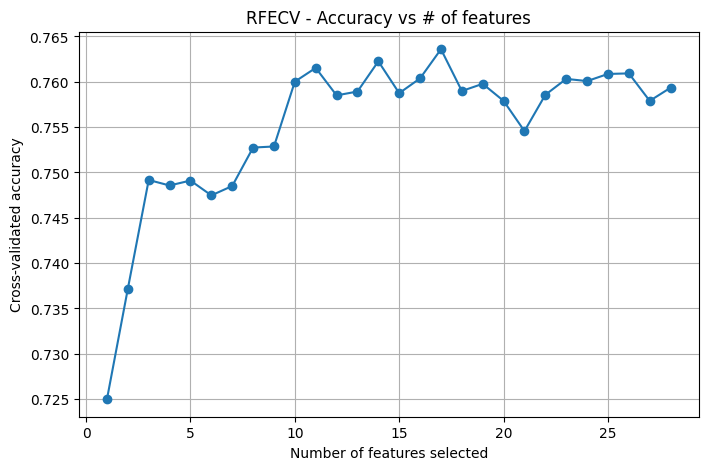

In [75]:
import matplotlib.pyplot as plt

scores = rfecv.cv_results_['mean_test_score']

plt.figure(figsize=(8,5))
plt.plot(range(1, len(scores) + 1), scores, marker='o')
plt.xlabel("Number of features selected")
plt.ylabel("Cross-validated accuracy")
plt.title("RFECV - Accuracy vs # of features")
plt.grid(True)
plt.show()

In [76]:
from itertools import product
X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

xgb = XGBClassifier()
xgb.fit(X_train_sel, y_train)

from sklearn.metrics import accuracy_score

y_pred = xgb.predict(X_test_sel)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC_AUC Score:", roc_auc_score(y_test, y_pred))

models = {}
xgb_params = {
        "n_estimators": [100, 200, 300, 500, 1000],
        "max_depth": [3, 4, 5, 6],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "learning_rate":[0.0001,0.001,0.01,0.1, 0.5]
    }
for ne, md, ss, cs, lr in product(
    xgb_params["n_estimators"],
    xgb_params["max_depth"],
    xgb_params["subsample"],
    xgb_params["colsample_bytree"],
    xgb_params["learning_rate"]
):
    name = f"XGB_ne{ne}_md{md}_ss{ss}_cs{cs}_lr{lr}"

    models[name] = XGBClassifier(
        n_estimators=ne,
        learning_rate=lr,
        max_depth=md,
        subsample=ss,
        colsample_bytree=cs,
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
        enable_categorical=True,
        eval_metric="logloss",
    )
models[name].fit(X_train_sel, y_train)


# catboost_params = {
#     "n_estimators": [100, 200, 300, 500, 1000],
#     "depth": [4, 6, 8, 10],
#     "l2_leaf_reg": [1, 3, 5, 7, 10],
#     "border_count": [32, 64, 128],
#     "learning_rate":[0.0001,0.001,0.01,0.1, 0.5]
# }
# for ne, depth, l2, bc, lr in product(
#     catboost_params["n_estimators"],
#     catboost_params["depth"],
#     catboost_params["l2_leaf_reg"],
#     catboost_params["border_count"],
#     catboost_params["learning_rate"],
# ):
#     name = f"Cat_ne{ne}_d{depth}_l2{l2}_b{bc}_lr{lr}"

#     models[name] = CatBoostClassifier(
#         n_estimators=ne,
#         learning_rate=lr,
#         depth=depth,
#         l2_leaf_reg=l2,
#         border_count=bc,
#         random_state=42,
#         verbose=False,
#         cat_features=categorical_cols, 
#     )

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
names = []
X_sel = X[selected_features]
print("\nCross-validation comparison (Stratified K-fold):\n")
for name, model in models.items():
    scores = cross_val_score(
        model,
        X_sel,
        y,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )
    results.append(scores)
    names.append(name)
    print(f"{name:20s}: mean={scores.mean():.4f}, std={scores.std():.4f}")

Accuracy: 0.7589047734431791
F1 Score: 0.5399907535829865
ROC_AUC Score: 0.678378492037603

Cross-validation comparison (Stratified K-fold):

XGB_ne100_md3_ss0.7_cs0.6_lr0.0001: mean=0.7083, std=0.0001
XGB_ne100_md3_ss0.7_cs0.6_lr0.001: mean=0.7083, std=0.0001
XGB_ne100_md3_ss0.7_cs0.6_lr0.01: mean=0.7098, std=0.0004
XGB_ne100_md3_ss0.7_cs0.6_lr0.1: mean=0.7671, std=0.0039
XGB_ne100_md3_ss0.7_cs0.6_lr0.5: mean=0.7645, std=0.0023
XGB_ne100_md3_ss0.7_cs0.8_lr0.0001: mean=0.7083, std=0.0001
XGB_ne100_md3_ss0.7_cs0.8_lr0.001: mean=0.7083, std=0.0001
XGB_ne100_md3_ss0.7_cs0.8_lr0.01: mean=0.7103, std=0.0011
XGB_ne100_md3_ss0.7_cs0.8_lr0.1: mean=0.7640, std=0.0060
XGB_ne100_md3_ss0.7_cs0.8_lr0.5: mean=0.7665, std=0.0027
XGB_ne100_md3_ss0.7_cs1.0_lr0.0001: mean=0.7083, std=0.0001
XGB_ne100_md3_ss0.7_cs1.0_lr0.001: mean=0.7083, std=0.0001
XGB_ne100_md3_ss0.7_cs1.0_lr0.01: mean=0.7110, std=0.0027
XGB_ne100_md3_ss0.7_cs1.0_lr0.1: mean=0.7663, std=0.0065
XGB_ne100_md3_ss0.7_cs1.0_lr0.5: mean=0.76

In [77]:
mean_results = []
for i in results:
    mean_results.append(i.mean())

mean_results.sort(reverse=True)
print(mean_results)

print(max(mean_results))



[np.float64(0.7739914641776527), np.float64(0.7735068506569356), np.float64(0.7734585654852519), np.float64(0.7734101980960538), np.float64(0.7733131814290367), np.float64(0.7732161530166606), np.float64(0.7731675624656374), np.float64(0.7731675154842007), np.float64(0.7730707337243676), np.float64(0.7730707337243676), np.float64(0.7729253731588709), np.float64(0.7729252909413564), np.float64(0.7729252909413564), np.float64(0.7728283564918538), np.float64(0.7727797894315492), np.float64(0.7726346050464405), np.float64(0.7725860262407769), np.float64(0.7725375766340644), np.float64(0.7725375296526276), np.float64(0.7725375296526276), np.float64(0.7724891740087886), np.float64(0.7724891152819925), np.float64(0.772489080045915), np.float64(0.77244066567528), np.float64(0.772392298286082), np.float64(0.7723921338510531), np.float64(0.7723437782072142), np.float64(0.7722953286005018), np.float64(0.772295293364424), np.float64(0.7722952463829872), np.float64(0.7722950936933175), np.float64(0

In [78]:
for n, r in zip(names, results):
    if r.mean() >= 0.7735:
        print(n, r.mean())



XGB_ne200_md4_ss0.7_cs1.0_lr0.1 0.7739914641776527
XGB_ne1000_md6_ss1.0_cs0.8_lr0.01 0.7735068506569356
